Week 1 : Introduction

This is the introduction week.

In [37]:
a = 2
b = 3
c = a + b
c

5

In [25]:
prices = [4,5,6]
prices

[4, 5, 6]

In [27]:
import numpy as np

In [31]:
prices_a = np.array([8.7,9.0,8.9])
prices_a

array([8.7, 9. , 8.9])

In [39]:
import pandas as pd
prices = pd.DataFrame({ "Blue" : [8.7,9.0,8.9], 
                       "Orange": [10.6,11.2,11.7]})
prices

                    

,Blue,Orange
0,8.7,10.6
1,9.0,11.2
2,8.9,11.7


In [63]:
prices = pd.read_csv("Desktop/FIN-666/data1_prices.csv")
prices.head(3)

,BLUE,ORANGE
0,8.7000,10.6600
1,8.9055,11.0828
2,8.7113,10.7100


In [65]:
returns = prices.pct_change()
returns.head()

,BLUE,ORANGE
0,NaN,NaN
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544


In [67]:
returns = returns.dropna()
returns

,BLUE,ORANGE
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249
10,0.006151,-0.168261


<Axes: >

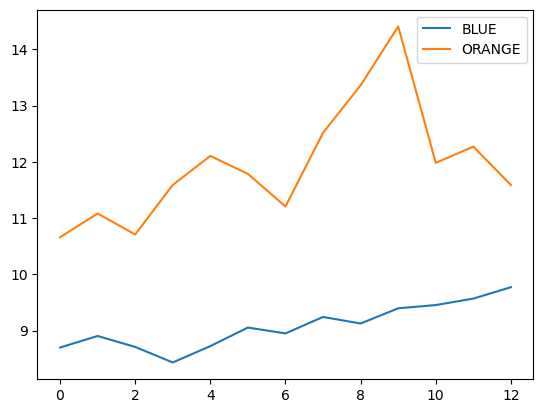

In [73]:
prices.plot()



<Axes: >

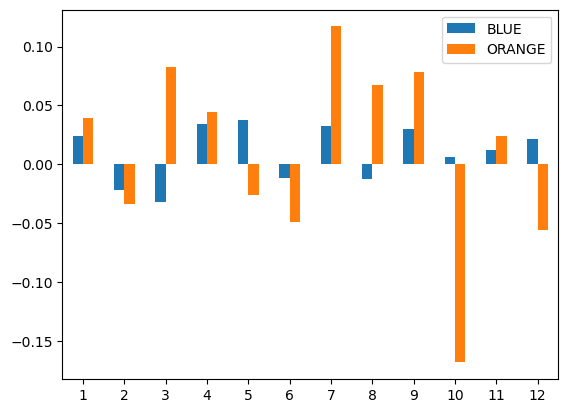

In [75]:
returns.plot.bar(rot=0)
            

In [77]:
returns.std()

BLUE      0.023977
ORANGE    0.079601
dtype: float64

In [79]:
returns.mean()


BLUE      0.01
ORANGE    0.01
dtype: float64

In [3]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Question 2: 80% CVaR Calculation
def cvar(returns, confidence=0.8):
    var = np.percentile(returns, 100 * (1 - confidence))
    cvar = np.mean(returns[returns <= var])
    return var, cvar

returns = np.array([-4, 5, 2, -7, 1, 0.5, -2, -1, -2, 5]) / 100
var_80, cvar_80 = cvar(returns)
print(f"80% VaR: {var_80:.2%}, 80% CVaR: {cvar_80:.2%}")

# Question 3: 95% Gaussian VaR Calculation
expected_return = 0.005  # 0.5%
volatility = 0.04  # 4%
z_95 = -1.65
var_95 = expected_return + z_95 * volatility
print(f"95% Gaussian VaR: {var_95:.2%}")

# Question 4: Cornish-Fisher Expansion
skewness = -1.2
kurtosis = 6
z_standard = -1.65
z_modified = z_standard + (1/6)*(z_standard**2 - 1)*skewness + (1/24)*(z_standard**3 - 3*z_standard)* (kurtosis - 3)
print(f"Modified z-score for 95%: {z_modified:.2f}")

# Question 7: Portfolio Analysis (Download data manually as per instructions)
# Load dataset (Assume CSV file is cleaned and loaded as 'df')
df = pd.read_csv("profitability_portfolios.csv")

def sharpe_ratio(returns, risk_free_rate=0.0):
    return (returns.mean() - risk_free_rate) / returns.std()

def semi_deviation(returns):
    return returns[returns < returns.mean()].std()

def drawdown(returns):
    wealth = (1 + returns).cumprod()
    peak = wealth.cummax()
    dd = (wealth - peak) / peak
    return dd

portfolios = ['Lo 10', 'Decile 5', 'Hi 10']
for p in portfolios:
    print(f"{p} Sharpe Ratio: {sharpe_ratio(df[p]):.2f}")
    print(f"{p} Semi-Deviation: {semi_deviation(df[p]):.2%}")
    dd = drawdown(df[p])
    print(f"{p} Max Drawdown: {dd.min():.2%}")
    plt.plot(dd, label=p)

plt.legend()
plt.title("Drawdown of Portfolios")
plt.show()


80% VaR: -2.40%, 80% CVaR: -5.50%
95% Gaussian VaR: -6.10%
Modified z-score for 95%: -1.94


FileNotFoundError: [Errno 2] No such file or directory: 'profitability_portfolios.csv'